# 04. PyTorch Custom Datasets Video Notebook

## 0. Imports and device agnostic code

In [98]:
import torch
from torch import nn

# device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 1. Get data
Our dataset is subset of 101 different classes of food - starts with 3 classes of food and only 10% of the images  (75. training, 25 testing).

Try thingson a small scales and then increase when necessary, speed up how fast you can experiment.

In [99]:
import requests
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pizza_steak_suhsi"

if image_path.is_dir():
  print(f"{image_path} directory already exists, skipping downloading")
else:
  print(f"{image_path} does not exists, creating one")
  image_path.mkdir(parents=True, exist_ok=True)

# Download
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading data...")
  f.write(request.content)

# Unzip data
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
  print("Unzipping data...")
  zip_ref.extractall(image_path)


data/pizza_steak_suhsi directory already exists, skipping downloading
Unzipping data...


## 2. Data preparation and data exploration

In [100]:
import os
def walk_through_dir(dir_path):
  """Returning dir_path contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_suhsi'.
There are 3 directories and 0 images in 'data/pizza_steak_suhsi/test'.
There are 0 directories and 19 images in 'data/pizza_steak_suhsi/test/steak'.
There are 0 directories and 25 images in 'data/pizza_steak_suhsi/test/pizza'.
There are 0 directories and 31 images in 'data/pizza_steak_suhsi/test/sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_suhsi/train'.
There are 0 directories and 75 images in 'data/pizza_steak_suhsi/train/steak'.
There are 0 directories and 78 images in 'data/pizza_steak_suhsi/train/pizza'.
There are 0 directories and 72 images in 'data/pizza_steak_suhsi/train/sushi'.


In [101]:
# Setup training and testing paths -- class names as a folder name under train/test folder -- root/class(e.g.sushi)/xxx.png -> torchvision.datasets style
train_dir = image_path / "train"
test_dir = image_path / "test"

### 2.1 Visualizing an image
1. Get all of the image paths
2. Pick a random image path using Pyton's `random.choice()`
3. Get the image class using `pathlib.Path.parent.stem`
4. Open the images eith Python's PIL
5. Show the image and print the metadata

Random image path: data/pizza_steak_suhsi/test/sushi/2521706.jpg
Image class: sushi
Image height: 512
Image width: 384


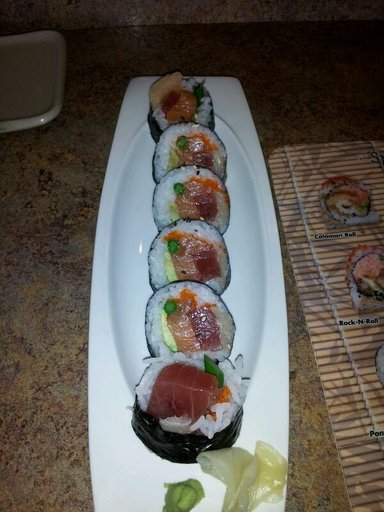

In [102]:
import random
from PIL import Image

random.seed(42)

# 1. Get all the image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(383.5), np.float64(511.5), np.float64(-0.5))

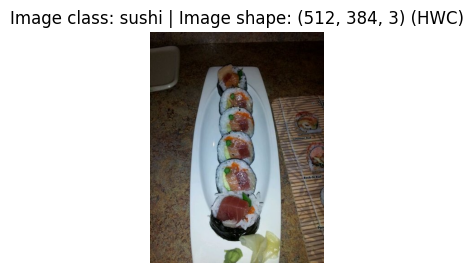

In [103]:
# Try to visualize and image with matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

plt.figure(figsize=(5,3))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} (HWC)")
plt.axis(False)

## 3. Transforming data

Before we can use our image data with PyTorch:
1. Turn your target data into tensors
2. Turn it into a `torch.utils.data.Dataset` and subsently a `torch.utils.data.DataLoader`, we'll cal these `Dataset` and `DataLoader` (iterable and batched version of Dataset).


In [104]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with `torch.transforms`

Transforms help you get your images ready to be used with a model and perform data augmentation.

In [105]:
data_transform = transforms.Compose([
  # resize your image
  transforms.Resize(size=(64,64)),
  # Flip the image randomly on the horizontal
  transforms.RandomHorizontalFlip(p=0.5),
  # turn the image into a torch.Tensor
  transforms.ToTensor()
])

data_transform(img).shape

torch.Size([3, 64, 64])

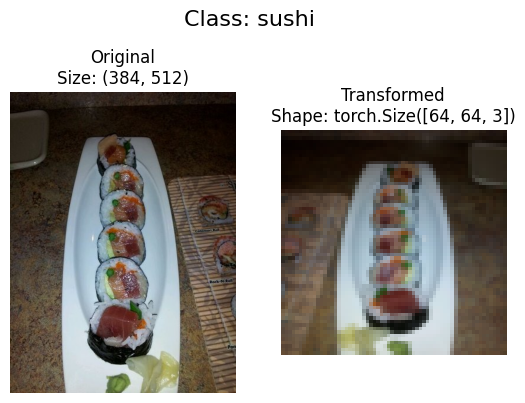

In [106]:
def plot_transformed_images(image_paths: list, transform, n=3, seed=None):
  """
  Selects random images from a path of images and loads/transforms
  them then plots the original vs the tranformed version
  """
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1, ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize: {f.size}")
      ax[0].axis(False)

      # Transform and plot target image
      transformed_image = transform(f).permute(1,2,0) # need to change shape for matplolib (C,H,W) -> (H,W,C)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis(False)

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths=image_path_list, transform=data_transform, n=1, seed=42)

## 4. Option 1: Loading image data using `ImageFolder`

We can load imae classification data using `torchvision.datasets.ImageFolder`

In [107]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,
                                  target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,
                                  transform=data_transform)
train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_suhsi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_suhsi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [108]:
train_dir, test_dir

(PosixPath('data/pizza_steak_suhsi/train'),
 PosixPath('data/pizza_steak_suhsi/test'))

In [109]:
# Get class names as a names
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [110]:
# Get class names as dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [111]:
# Check the lengths of our dataset
len(train_data), len(test_data)

(225, 75)

In [112]:
train_data.targets[:5], train_data.samples[:5]

([0, 0, 0, 0, 0],
 [('data/pizza_steak_suhsi/train/pizza/1008844.jpg', 0),
  ('data/pizza_steak_suhsi/train/pizza/1033251.jpg', 0),
  ('data/pizza_steak_suhsi/train/pizza/1044789.jpg', 0),
  ('data/pizza_steak_suhsi/train/pizza/1089334.jpg', 0),
  ('data/pizza_steak_suhsi/train/pizza/1105700.jpg', 0)])

In [113]:
# Index on the train_data Dataset to get a single image and label
img, label = train_data[5][0], train_data[5][1]
img.shape, img.dtype # image tensor

(torch.Size([3, 64, 64]), torch.float32)

In [114]:
class_names[label]

'pizza'

Text(0.5, 1.0, 'pizza')

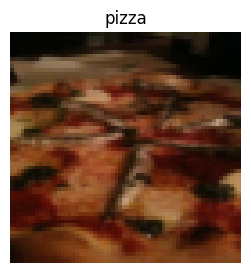

In [115]:
# Rearrange the order dimensions
img_permute = img.permute(1,2,0)

# Plot the image
plt.figure(figsize=(5,3))
plt.imshow(img_permute)
plt.axis(False)
plt.title(class_names[label])

## 4.1 Turn loaded images into `DataLoader`'s

A `DataLoader` is going to help us turn out `Dataset`'s into iterables and we can customize `batch_size` so our model can see  `batch_size` images at a time.

In [116]:
import os
os.cpu_count()

2

In [117]:
from torch.utils.data import DataLoader
BATCH_SIZE=1
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=1,#os.cpu_count()
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              num_workers=1,
                             shuffle=False)
train_dataloader, test_dataloader



(<torch.utils.data.dataloader.DataLoader at 0x7e46b47fa350>,
 <torch.utils.data.dataloader.DataLoader at 0x7e46b47fa150>)

In [118]:
len(train_dataloader), len(test_dataloader)

(225, 75)

In [119]:
img, label = next(iter(train_dataloader))

# batch size will now be 1, you can chance if you like
print(f"Image shape: {img.shape} -> [batch_size, color_channel, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channel, height, width]
Label shape: torch.Size([1])


## 5. Option 2: Loading image data with a custom `Dataset`
1. Want to be able to load images from file
2. get class names from the Dataset
3. get classes as dictionary from the Dataset

All custom datasets in PyTorch, often subclass torch.utils.data.Dataset


In [120]:
import os
import pathlib
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [121]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names
We want a funciton to:
1. Get the class names using `os.scandir()` to transverse a target directory (ideally directory is in standard image classification format)
2. Raise an error if the class names are not found (might be wrong directory structure)
3. Turn the class names into a dict and a list and return them.

In [122]:
# Setup path for target directory
target_directory = train_dir
print(target_directory)

# get the class names from the target directory

class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

data/pizza_steak_suhsi/train


['pizza', 'steak', 'sushi']

In [123]:
list(os.scandir(target_directory))

[<DirEntry 'steak'>, <DirEntry 'pizza'>, <DirEntry 'sushi'>]

In [124]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
  """Finds the classes folder names in a target directory"""
  # 1. Get the class names by scanning the target directory
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  # 2. Raise an error if class names could not be found
  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}.")

  # 3. Create a dictionary of index labels
  class_to_idx = {class_name: i for i, class_name in enumerate(classes)}

  return classes, class_to_idx

find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom `Dataset` to replicate `ImageFolder`
To create our own custom dataset:
1. Subclass `torch.utils.data.Dataset`
2. Init our subclass with a target directory (the directory we'd like to get data from) as well as a transform if we'd like to transform oır data
3. Create several attributes:
* paths - paths of our images
* transform - the transform we'd like to use
* classes - a list of the target classes
* class_to_idx - a dict of the target classes mapped to integer labels
4. Create a function to `load_iamges()`, this function will open an image
5. Overwrite the `__len()__` method (optional overwrite)
6. Overwrite the `__get_item()__` to return a given sample when passes an index (mandatory overwrite)

In [125]:
# Custom dataset class
from torch.utils.data import Dataset

# 1. Subclass
class ImageFolderCustom(Dataset):
  # 2. Initialize
  def __init__(self, targ_dir: str, transform=None):
    # 3. Create class attributes
    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    # Setup transform
    self.transform = transform
    # classes and class_to_idx attributes
    self.classes, self.class_to_idx = find_classes(targ_dir)

  # 4. Create a function to load image
  def load_image(self, index:int) -> Image.Image:
    "Opens an image via a path and returns it."
    image_path = self.paths[index]
    return Image.open(image_path)

  # 5. Overwrite __len__()
  def __len__(self) -> int:
    "Returns the total numbers of samples."
    return len(self.paths)

  # 6. Overwrite __get_item__() method to return a particular sample
  def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        "Returns one sample of data, data and label (X, y)."
        img = self.load_image(index)
        class_name  = self.paths[index].parent.name # expects path in data_folder/class_name/image.jpeg
        class_idx = self.class_to_idx[class_name]

        # Transform if necessary
        if self.transform:
            return self.transform(img), class_idx # return data, label (X, y)
        else:
            return img, class_idx # return data, label (X, y)

In [126]:
from torchvision import transforms
# Create a transform
train_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()]
)
test_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()]
)

In [127]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transforms)
test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                      transform=test_transforms)
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7e46b491a900>,
 <__main__.ImageFolderCustom at 0x7e469abe5450>)

In [128]:
len(train_data), len(train_data_custom)

(225, 225)

In [129]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [130]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [131]:
print(train_data_custom.classes==train_data.classes)
print(test_data_custom.classes==test_data.classes)

True
True


## 5.3 Create a function to display random images
1. Take in a `Dataset` and a number of other parameters such as class names and how many images to visualize
2. To prevent the display getting out of hand, let's cap the number of images to see at 10.
3. Set the random seed for reproducibility
4. Get a number of sample indexes from the target dataset
5. Setup a matplotlib plot
6. Loop through the random sample indexes and plot them with matplotlib
7. Make sure the dimensions of our images line up with matplotlib (HWC)

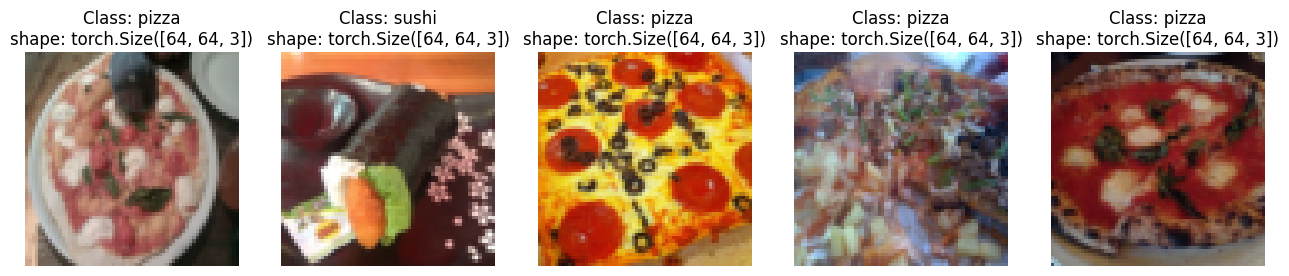

In [132]:
# 1. Crate a function to take in a dataset
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape : bool = True,
                          seed: int = None):
  # 2. Adjust the display if n is too high
  if n > 10:
    n = 10
    display_shape = False
    print("For display, n shouldn't be larger than 10, setting to 10.")

  # 3. Set the seed
  if seed:
    random.seed(seed)

  # 4. Get the random sample indexes
  random_sample_idx = random.sample(range(len(dataset)), k=n) # k tane seçilir

  # 5. Setup plot
  plt.figure(figsize=(16,8))

  # 6. Loop through the random sample indexes and plot them with matplotlib
  for i, targ_sample in enumerate(random_sample_idx):
    targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

    # 7. Adjust tensor dimensions for plotting
    targ_image_adjust = targ_image.permute(1,2,0)

    # plot adjusted samples
    plt.subplot(1, n, i+1)
    plt.imshow(targ_image_adjust)
    plt.axis("off")
    if classes:
      title = f"Class: {classes[targ_label]}"
      if display_shape:
        title = title + f"\nshape: {targ_image_adjust.shape}"
    plt.title(title)


display_random_images(train_data, n=5, classes=class_names, seed=None)

For display, n shouldn't be larger than 10, setting to 10.


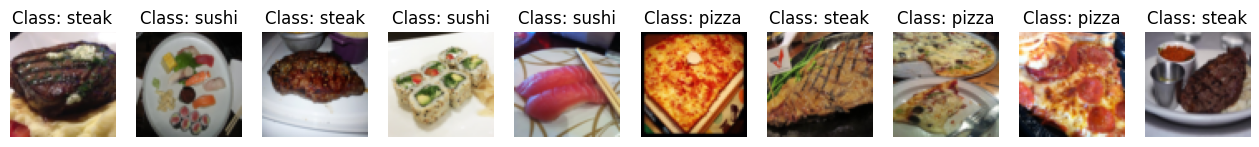

In [133]:
# Display random images from the ImageFolderCustom Dataset
display_random_images(train_data_custom, n=20, classes=class_names, seed=None)

## 5.4 Trun custon loaded images into `DataLoader`'s

In [134]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=BATCH_SIZE,
                                     num_workers=NUM_WORKERS,
                                     shuffle=True)
test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                     batch_size=BATCH_SIZE,
                                     num_workers=NUM_WORKERS,
                                     shuffle=False)
train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7e46ff728a50>,
 <torch.utils.data.dataloader.DataLoader at 0x7e46d9c27d50>)

In [135]:
# Get image and label from custom dataloader
img_custom, label_custom = next(iter(train_dataloader_custom))
img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

## 6. Other forms of transofroms (data augmentations)
Artificially adding diversity to to your training data.


In [136]:
# Let's look at trivial augment
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

In [137]:
# Get all the image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

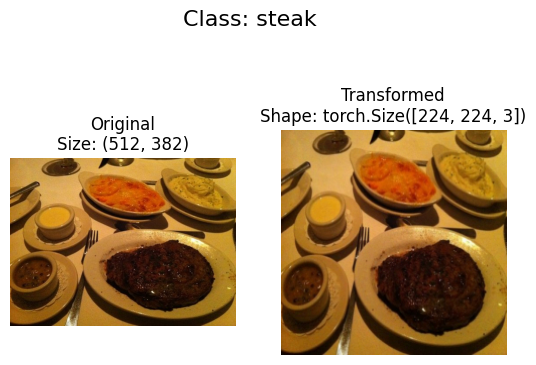

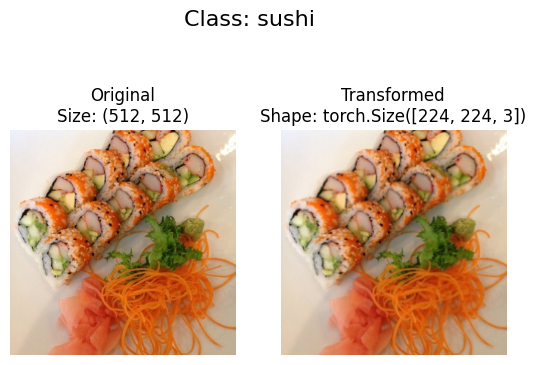

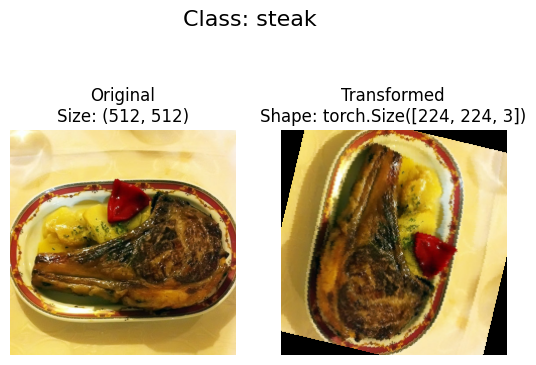

In [138]:
# Plot random images
plot_transformed_images(image_path_list, train_transform, n=3, seed=None)

## 7. Model 0: TinyVGG without data augmentation

### 7.1 Creating transforms and loading data for Model 0

In [139]:
# Create simple transform
simple_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [140]:
# 1. Load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                  transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                  transform=simple_transform)

# 2. Turn the datasets into DataLoaders
from torch.utils.data import DataLoader
BATCH_SIZE=32
NUM_WORKERS=os.cpu_count()
train_dataloader_simple = DataLoader(dataset=train_data_simple,
                              batch_size=BATCH_SIZE,
                              num_workers=NUM_WORKERS,
                              shuffle=True)
test_dataloader_simple = DataLoader(dataset=test_data_simple,
                              batch_size=BATCH_SIZE,
                              num_workers=NUM_WORKERS,
                              shuffle=False)

### 7.2 Create TinyVGG model class

In [141]:
class TinyVGG(nn.Module):
  def __init__(self, input_shape: int,
               hidden_units: int,
               output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(input_shape, hidden_units, kernel_size=3, stride=1, padding=0),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=0),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(hidden_units*13*13, output_shape) # burada input shape bulmak için forward methodunda x.shape yazdırırız
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    #print(x.shape)
    x = self.conv_block_2(x)
    #print(x.shape)
    x = self.classifier(x)
    #print(x.shape)
    return x
    # return self.classifier(self.conv_block_2(self.conv_block_1(x))) # benefits from operation fusion

In [142]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, # number of color channels
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

### 7.3 Try a forwasrd pass on a single image (to test the model)

In [143]:
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [144]:
model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4668e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9131e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6415e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0239e-02, -4.7979e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1816e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3995e-03,  9.4990e-03],
        [ 2.2101e-02, -4.1469e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.1665e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

### 7.4 Use `torchinfo` to get an idea of shapes going through our model

In [145]:
# install torchinfo
try:
  import torchinfo
except:
  !pip install torchinfo

from torchinfo import summary
summary(model_0, input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

## 7.5 Create train and test loop functions
* `train_step()` - takes in a model and dataloader and trains the model on the dataloader
* `test_step()` - takes in model and dataloader and evaluates the model on the dataloader

In [146]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device=device):
  # Put the model in train mode
  model.train()

  # step train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # loop through data loader data batches
  for batch, (X,y) in enumerate(dataloader):
    # send data to the target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X) # output model logits

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Calculate accuracy metric
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class==y).sum().item() / len(y_pred_class)

  # Adjust metrics to get average loss and accuracy per batch
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

In [147]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device=device):
  # Put the model in eval mode
  model.eval()

  # step test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference mode
  with torch.inference_mode():

    # loop through data loader data batches
    for batch, (X,y) in enumerate(dataloader):
      # send data to the target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      test_pred_logits = model(X) # output model logits

      # 2. Calculate the loss
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += (test_pred_labels==y).sum().item() / len(test_pred_labels)

  # Adjust metrics to get average loss and accuracy per batch
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

### 7.6 Creating a `train()` function to combine `train_step()` and `test_step()`

In [148]:
from tqdm.auto import tqdm

# 1. Create a train funcitom
def train(model: torch.nn.Module,
          train_data: torch.utils.data.DataLoader,
          test_data: torch.utils.data.DataLoader,
          optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device=device):
  # 2. Create empty results dictionary
  results = {"train_loss": [],
              "train_acc": [],
              "test_loss": [],
              "test_acc": [] }

  # 3. Loop through training and testing steps for epochs
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                      dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       device=device)
    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device)

    # 4. print out what's happening
    print(f"Epoch: {epoch} | Train loss: {train_loss:.4f}| Train accuracy: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

    # 5. update results dict
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # 6. return filled results
  return results

### 7.7 Train and evaluate model 0

In [149]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

# recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3, # number of color channels
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)
# Start the timer
from timeit import default_timer as timer
start_time = timer()

model_0_results = train(model=model_0,
                        train_data=train_dataloader_simple,
                        test_data=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 1.1011| Train accuracy: 0.3467 | Test loss: 1.0881 | Test accuracy: 0.4533
Epoch: 1 | Train loss: 1.0373| Train accuracy: 0.4933 | Test loss: 1.0456 | Test accuracy: 0.4267
Epoch: 2 | Train loss: 1.0097| Train accuracy: 0.5422 | Test loss: 1.0074 | Test accuracy: 0.5200
Epoch: 3 | Train loss: 0.9526| Train accuracy: 0.6000 | Test loss: 0.9843 | Test accuracy: 0.4800
Epoch: 4 | Train loss: 0.9113| Train accuracy: 0.6044 | Test loss: 0.9922 | Test accuracy: 0.5200
Total training time: 28.277 seconds


### 7.8 Plot the loss curves of Model 0
A **loss curve** is a way of tracking your model's progress over time.

In [150]:
# Get the model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

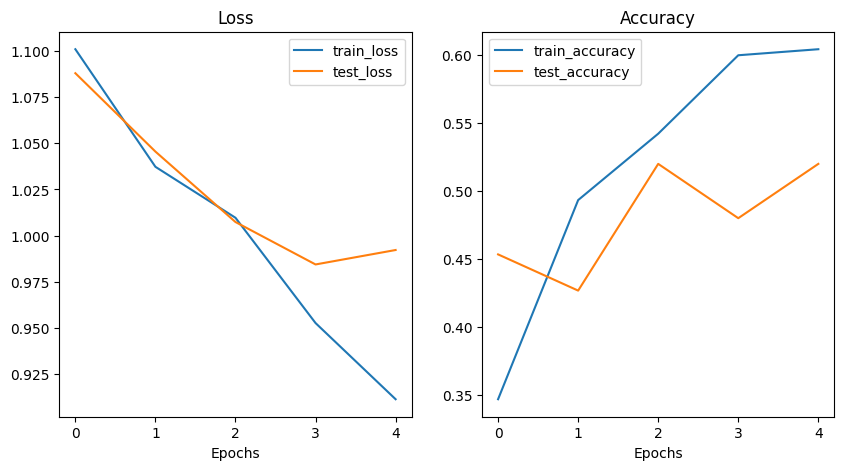

In [151]:
def plot_loss_curves(results: Dict[str, List[float]]):
  """Plots training curves of a result dictionary."""
  loss = results["train_loss"]
  test_loss = results["test_loss"]
  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  # figure out how many epochs there were
  epochs = range(len(results["train_loss"]))

  plt.figure(figsize=(10,5))
  plt.subplot(1,2,1)
  plt.plot(epochs, loss, label="train_loss")
  plt.plot(epochs, test_loss, label="test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(epochs, accuracy, label="train_accuracy")
  plt.plot(epochs, test_accuracy, label="test_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()


plot_loss_curves(model_0_results)

## 8. What should an ideal loss curve look like?

## 9. Model 1: TinyVGG with data augmentation
Using the same model as before with some data augmentation.

### 9.1 Create transfrom with data augmentation

In [152]:
# Create training transform with TrivialAugment
from torchvision import transforms
train_transform_trivial = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])
test_transform_simple = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

### 9.2 Create train and test `Dataset`'s and `DataLoader`'s with data augmentation

In [153]:
# turn image folders into Datasets
from torchvision import datasets
train_data_augmented = datasets.ImageFolder(root=train_dir,
                                            transform=train_transform_trivial)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                            transform=test_transform_simple)

# Turn Datasets into DataLoaders
import os
from torch.utils.data import DataLoader
BATCH_SIZE=32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(dataset=train_data_augmented,
                                        batch_size=BATCH_SIZE,
                                        shuffle=True,
                                        num_workers=NUM_WORKERS)
test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                        batch_size=BATCH_SIZE,
                                        shuffle=False,
                                        num_workers=NUM_WORKERS)

### 9.3 Construct and train Model 1
Same model architecture with augmented training data

In [154]:
# create model_1 and send it to the target device
torch.manual_seed(42)
model_1 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data_augmented.classes)).to(device)
model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [155]:
# train and evaluate the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

from timeit import default_timer as time
start_time = timer()

model_1_results = train(model=model_1,
                        train_data=train_dataloader_augmented,
                        test_data=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        device=device)
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 1.1074| Train accuracy: 0.3244 | Test loss: 1.1001 | Test accuracy: 0.3333
Epoch: 1 | Train loss: 1.0987| Train accuracy: 0.3467 | Test loss: 1.1004 | Test accuracy: 0.3333
Epoch: 2 | Train loss: 1.0988| Train accuracy: 0.3467 | Test loss: 1.1010 | Test accuracy: 0.3333
Epoch: 3 | Train loss: 1.0987| Train accuracy: 0.3467 | Test loss: 1.1010 | Test accuracy: 0.3333
Epoch: 4 | Train loss: 1.1019| Train accuracy: 0.3467 | Test loss: 1.1017 | Test accuracy: 0.3333
Total training time: 16.522 seconds


### 9.4 Plot the loss curves of model 1

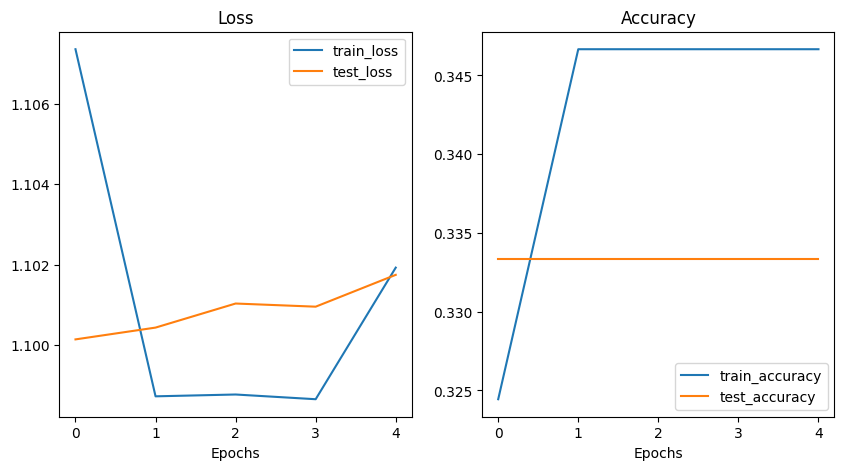

In [156]:
plot_loss_curves(model_1_results)

## 10. Compare model results
There's a few different aways to do this:
1. Hard coding (what we're doing)
2. PyTorch + Tensorboard
3. Weights & Biases
4. MLFlow

In [157]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.101053,0.346667,1.088050,0.453333
1,1.037301,0.493333,1.045553,0.426667
2,1.009660,0.542222,1.007353,0.520000
3,0.952577,0.600000,0.984346,0.480000
4,0.911275,0.604444,0.992180,0.520000


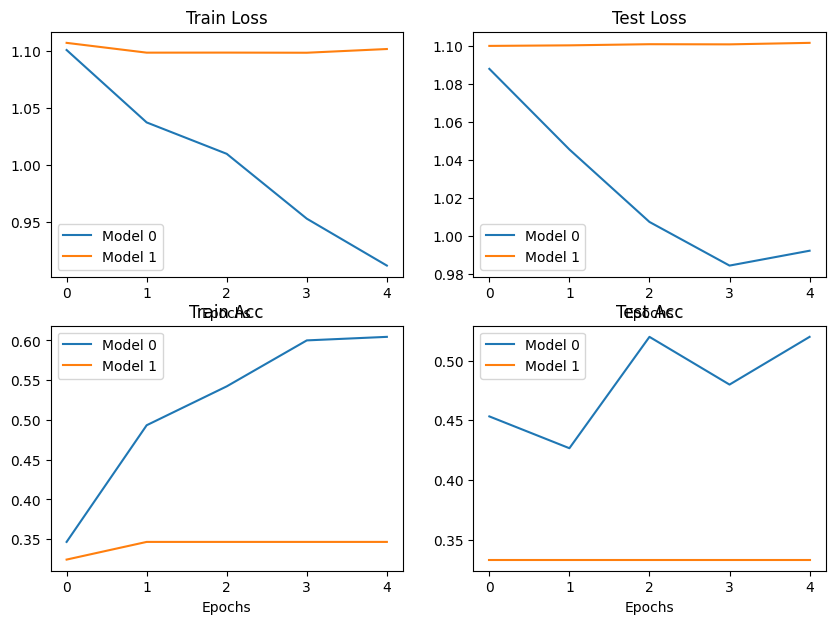

In [158]:
# setup a plot
plt.figure(figsize=(10,7))

epochs = range(len(model_0_df))

# plot train loss
plt.subplot(2,2,1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# plot test loss
plt.subplot(2,2,2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# plot train accuracy
plt.subplot(2,2,3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.title("Train Acc")
plt.xlabel("Epochs")
plt.legend()

# plot test accuracy
plt.subplot(2,2,4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")
plt.title("Test Acc")
plt.xlabel("Epochs")
plt.legend()

## 11. Making a prediction on a custom image
Making a prediction on a sample/image that's not in either training or testing data

In [159]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = data_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

data/04-pizza-dad.jpeg already exists, skipping download.


## 11.1 Loading in a custom imahe with PyTorch
We have to make sure our custom image is in the same format as the data our model was trained on.
* In tensor form with datatype (torch.float32)
* of shape 64x64x3
* on the right device

In [160]:
import torchvision

# read in custom image
custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))
custom_image_uint8

tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)

Custom image shape: torch.Size([3, 4032, 3024])

Custom image dtype: torch.uint8


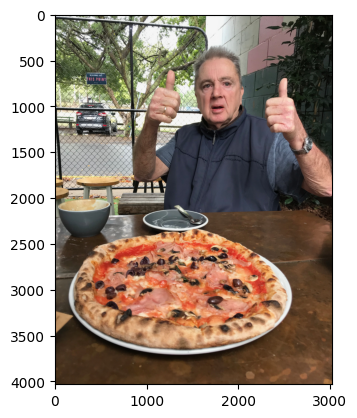

In [161]:
plt.imshow(custom_image_uint8.permute(1,2,0))
print(f"Custom image shape: {custom_image_uint8.shape}\n")
print(f"Custom image dtype: {custom_image_uint8.dtype}")

### 11.2 Making a prediction on a custom image

In [162]:
# try to make prediction on an image in uint8 format -> error
custom_image = custom_image_uint8.type(torch.float32) / 255.

# create transform pipeline to resize image
custom_image_transform = transforms.Compose([transforms.Resize(size=(64,64))])

custom_image_transformed = custom_image_transform(custom_image)

custom_image_transformed.shape

torch.Size([3, 64, 64])

In [164]:
# shape mismatch -> no batch size
# model_1.eval()
# with torch.inference_mode():
  # custom_image_pred = model_1(custom_image_transformed.to(device))

In [165]:
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_transformed.unsqueeze(0).to(device))
custom_image_pred

tensor([[ 0.0226, -0.0056, -0.0406]])

Note: to make a prediction on a custom image we had to:
* Load the image and turn it into a tensor
* Make sure the imahe was the same datatype as the model  (torch.flooat32)
* same shape as the data the model was trained on (3,64,64) witha batch size (1,3,64,64)
* make sure the image was on the same device as out model

In [166]:
# convert logits -> prediciton probabilities
custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
custom_image_pred_probs


tensor([[0.3435, 0.3340, 0.3225]])

In [167]:
# convert precition probabilities -> prediciton labels
custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
custom_image_pred_label

tensor([0])

In [168]:
class_names[custom_image_pred_label]

'pizza'

### 11.3 Putting custom image prediction together: building a function
Ideal outcome:
A function where we pas an image path to and have our model predict on the image and plot the image + prediction

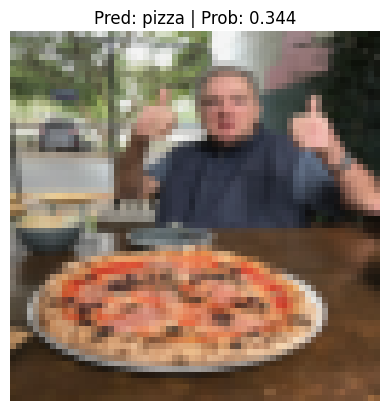

In [171]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform=None,
                        device=device):

  """Makes a prediction on a target image and plots the image with its prediction."""


  # Load the image
  target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

  # pixel values between [0,1]
  target_image = target_image / 255.

  # transfrom if necessary
  if transform:
    target_image = transform(target_image)

  # make sure the model is on the target device
  model.to(device)

  # make prediciton
  model.eval()
  with torch.inference_mode():
    target_image = target_image.unsqueeze(0) # extra batch dimension
    target_image_pred = model(target_image.to(device))

  # convert the logits to labels.
  target_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
  target_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)

  plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib
  if class_names:
      title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
  else:
      title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
  plt.title(title)
  plt.axis(False)


pred_and_plot_image(model=model_1,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)